# Visualizing Data in Roman ASDF Files with `matplotlib`

***

## Kernel Information and Read-Only Status

To run this notebook, please select "Roman Research Nexus {VERSION}" kernel at the top right of your window. For example "Roman Research Nexus 2026.2".

This notebook is read-only. You can run cells and make edits, but you must save changes to a different location. We recommend saving the notebook within your home directory, or to a new folder within your home (e.g. <span style="font-variant:small-caps;">file > save notebook as > my-nbs/nb.ipynb</span>). Note that a directory must exist before you attempt to add a notebook to it.

## Introduction
This tutorial demonstrates how to visualize and explore Roman WFI image data arrays by creating static images with world coordinate system (WCS) overlays in `matplotlib`.

We focus on how to visualize WFI Level 2 (L2; calibrated rate image) data in ASDF format. For WFI, L2 indicates that the data have been processed to flag and/or correct for detector-level effects (e.g., saturation, classic non-linearity, etc.) and the resultants fitted into a count rate image. Each L2 ASDF file contains a single WFI detector, thus a complete WFI exposure is made up of 18 L2 files. For more information WFI L2 files, please see the RDox article on [Data Levels and Products](https://roman-docs.stsci.edu/data-handbook-home/wfi-data-format/data-levels-and-products#DataLevelsandProducts-Level2-CalibratedExposuresLevel2).

## Imports
- *astropy.visualization.simple_norm* for automatically scaling image arrays
- *astropy.wcs.WCS* to create Astropy WCS objects
- *matplotlib.pyplot* for creating static image previews
- *numpy* for array calculations and manipulation
- *roman_datamodels* for opening Roman WFI ASDF files
- *s3fs* to access data in an AWS S3 bucket

In [1]:
%matplotlib inline
import os
from astropy.visualization import simple_norm
from astropy.wcs import WCS
import matplotlib.pyplot as plt
import numpy as np

import roman_datamodels as rdm
import s3fs

## Loading data
Note that the static image portions can be used on any `numpy.ndarray` object, and the WCS axes may be optionally included with any `astropy.wcs.WCS` object.

A complete explanation on how to load and work with Roman ASDF files is provided in the notebook tutorial [Working with ASDF](../working_with_asdf/working_with_asdf.ipynb). We read in the data using the `roman_datamodels` package:

In [2]:
file_system = s3fs.S3FileSystem(anon=True)

s3_bucket = "s3://stpubdata/roman/nexus/soc_simulations/tutorial_data/roman-2026.1/"
image_prefix = s3_bucket + 'r0003201001001001004_0001_wfi01_f106_cal.asdf'
file = rdm.open(
    file_system.open(image_prefix, 'rb')
)

/home/runner/micromamba/envs/ci-env/lib/python3.12/site-packages/asdf/_asdf.py:274: AsdfPackageVersionWarning: File was created with extension URI 'asdf://stsci.edu/datamodels/roman/extensions/static-1.1.0' (from package roman_datamodels==0.30.1), which is not currently installed
  warnings.warn(msg, AsdfPackageVersionWarning)


## Static Image Display

### Plot an Image with Dynamic Scaling

Here we show how to use matplotlib and Astropy to plot the data array from our WFI image and scale the array automatically.

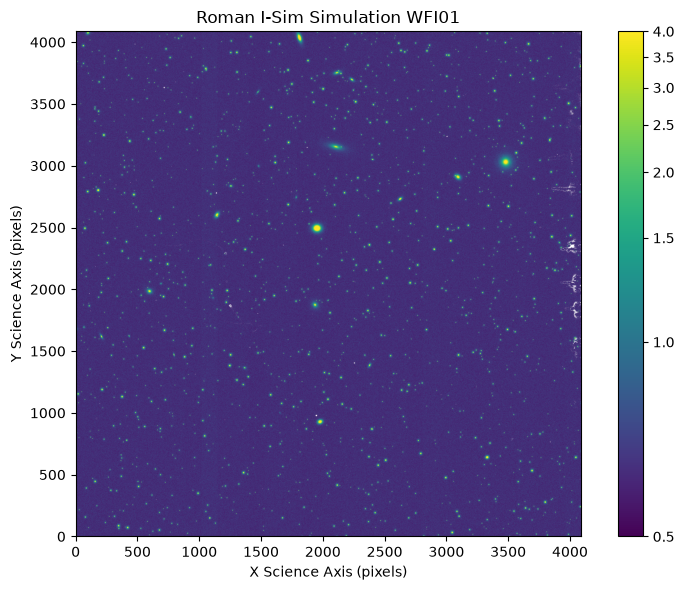

In [3]:
# Set the image normalization. Here we use a inverse hyperbolic sine scale 
# with the minimum and maximum of the range specified as 0.5 to 4 DN/s.
# These limits can be adjusted based on examination of the pixel values
# (e.g., a histogram).
norm = simple_norm(file.data, 'asinh', vmin=0.5, vmax=4)

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.imshow(file.data, norm=norm, origin='lower')
ax.set(
    xlabel='X Science Axis (pixels)',
    ylabel='Y Science Axis (pixels)',
    title='Roman I-Sim Simulation WFI01'
)
plt.colorbar(sc, ax=ax)
plt.tight_layout();

We can see a bright, extended source near the center of this image. We isolate and examine that region a little more closely. Based on the image above, let's isolate science Y coordinates 2600 - 3500 and science X coordinates 3000 - 3950.

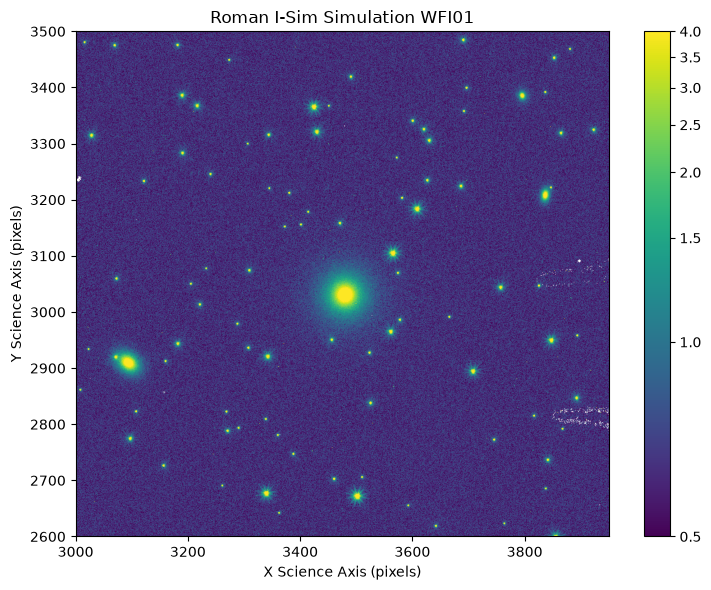

In [4]:
# Close the previous figure
plt.close()

# Make new figure zoomed in on 3000 <= X <= 3950 and 2600 <= Y <= 3500:
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.imshow(file.data, norm=norm, origin='lower')
ax.set(
    xlabel='X Science Axis (pixels)',
    ylabel='Y Science Axis (pixels)',
    title='Roman I-Sim Simulation WFI01',
    xlim=(3000, 3950),
    ylim=(2600, 3500)
)
plt.colorbar(sc, ax=ax)
plt.tight_layout();

We can see some strange features in the right side of this image. They were also in the previous plot, but were not as evident at the previous level of zoom. These features are not some interesting new science, but are actually instrumental artifacts, and we can see in the data quality (DQ) array that they are marked for our reference in any analysis we may perform. Not all artifacts or DQ flags are necessarily bad for analysis, but here we show all pixels with DQ values > 0 (any quality flags; white) compared to pixels with DQ values equal to 0 (good; black). For more information on how to work with DQ flags, see the [Working with ASDF](../working_with_asdf/working_with_asdf.ipynb) tutorial. The [Detector Performance](https://stsci-docs.stsci.edu/spaces/DRAFTSOC/pages/90800741/WFI+Detectors#WFIDetectors-SummaryofWFIPerformanceContent) article and the articles under it will provide detail on instrumental artifacts and detector performance. Please note that several analyses are still ongoing and RDox will be updated in the future.

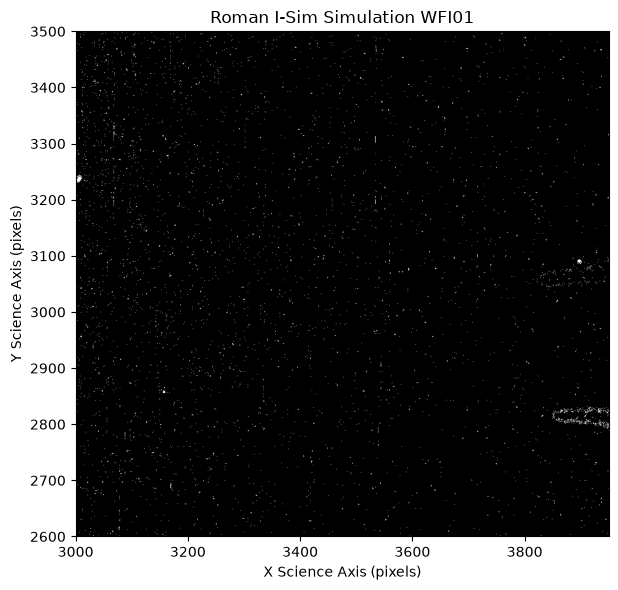

In [5]:
# Close the previous figure
plt.close()

# Display the data quality (DQ) array for the same region.
# Convert the DQ values to boolean True (bad) and False (good) for simple display.
# The binary colormap normally goes from white to black, but we have inverted it
# using binary_r to ease visibility of flagged pixels.
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(np.bool(file.dq), origin='lower', cmap='binary_r')
ax.set(
    xlabel='X Science Axis (pixels)',
    ylabel='Y Science Axis (pixels)',
    title='Roman I-Sim Simulation WFI01',
    xlim=(3000, 3950),
    ylim=(2600, 3500)
)
plt.tight_layout();

If we want to add information about the sky coordinates rather than displaying the image in pixels, we can use the `gwcs.wcs.WCS` object in the file metadata. To overlay the coordinate grid, however, we will need to transform the WCS to an `astropy.wcs.WCS` object, which needs a FITS Simple Imaging Polynomial (SIP) representation of the WCS. 

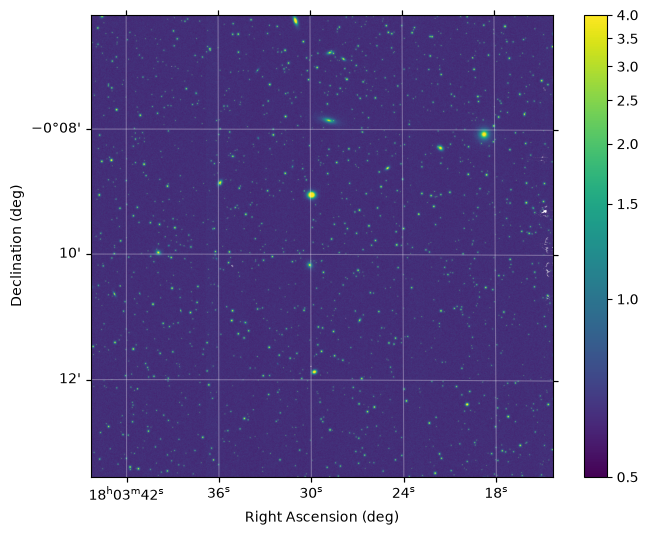

In [6]:
# Close the previous figure
plt.close()

# Set the matplotlib backend (change this to "%matplotlib widget" for interactive plots)
%matplotlib inline

fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': WCS(file.meta.wcs.to_fits_sip())})
sc = ax.imshow(file.data, norm=norm, origin='lower')
ax.imshow(file.data, norm=norm, origin='lower')
plt.colorbar(sc, ax=ax)
ax.grid(color='white', alpha=0.3)

ax.set(
    xlabel='Right Ascension (deg)',
    ylabel='Declination (deg)',
)

plt.show()

In [7]:
# Close figures before proceeding
plt.close('all')

We can also use `matplotlib` to examine the image interactively using the `%matplotlib widget` magic command. To do this, try re-running the cell above, but replacing `%matplotlib inline` with `%matplotlib widget`. If you use this command, you will see some basic icons on the left of the image that allow you to pan, zoom, return to the original display, and save the current view to a file. Notice that the WCS gridlines will adjust for different levels of zoom. You can do this for any of the `matplotlib` plots above.

## Additional Resources

- [RDox WFI Data Levels and Products](https://roman-docs.stsci.edu/data-handbook-home/wfi-data-format/data-levels-and-products#DataLevelsandProducts-L2ScienceDataSpecifications)

## About this Notebook
**Author:** Tyler Desjardins, Brett Morris, R. Diaz  
**Updated On:** 2026-07-14

<table width="100%" style="border:none; border-collapse:collapse;">
  <tr style="border:none;">
    <td style="border:none; width:180px; white-space:nowrap;">
       <a href="#top" style="text-decoration:none; color:#0066cc;"> Top of page</a>
    </td>
    <td style="border:none; text-align:center;">
        <img src="https://raw.githubusercontent.com/spacetelescope/roman_notebooks/refs/heads/main/roman_logo.png" alt="roman_logo" width="50px">
    </td>
    <td style="border:none; text-align:right;">
       <img src="https://raw.githubusercontent.com/spacetelescope/roman_notebooks/refs/heads/main/stsci_logo2.png" width="90">
    </td>
  </tr>
</table>